In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [5]:
data = fetch_openml(name="wine", version=2, as_frame=True)
X_full = data.data.copy()

In [6]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malic_acid                    178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  OD280/OD315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: fl

Scalling the data to min-max scale

In [9]:
scaler = MinMaxScaler() #data [0,1] #giving better result
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

#scaler = StandardScaler()
#X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [10]:
GroundTruth = X_full.copy()
X = X_full.copy()
print(GroundTruth)

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0    0.842105    0.191700  0.572193           0.257732   0.619565   
1    0.571053    0.205534  0.417112           0.030928   0.326087   
2    0.560526    0.320158  0.700535           0.412371   0.336957   
3    0.878947    0.239130  0.609626           0.319588   0.467391   
4    0.581579    0.365613  0.807487           0.536082   0.521739   
..        ...         ...       ...                ...        ...   
173  0.705263    0.970356  0.582888           0.510309   0.271739   
174  0.623684    0.626482  0.598930           0.639175   0.347826   
175  0.589474    0.699605  0.481283           0.484536   0.543478   
176  0.563158    0.365613  0.540107           0.484536   0.543478   
177  0.815789    0.664032  0.737968           0.716495   0.282609   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0         0.627586    0.573840              0.283019         0.593060   
1         0.575862    0.5

Converting GroundTruth to tensor

In [11]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [12]:
GroundTruth.nunique()

Alcohol                         126
Malic_acid                      133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
OD280/OD315_of_diluted_wines    122
Proline                         121
dtype: int64

In [13]:
print("Alcohol",GroundTruth['Alcohol'].unique())
print("Malic_acid",GroundTruth['Malic_acid'].unique())
print("Ash",GroundTruth['Ash'].unique())
print("Alcalinity_of_ash",GroundTruth['Alcalinity_of_ash'].unique())
print("Magnesium",GroundTruth["Magnesium"].unique())
print("Total_phenols",GroundTruth['Total_phenols'].unique())
print("Flavanoids",GroundTruth['Flavanoids'].unique())
print("Nonflavanoid_phenols",GroundTruth['Nonflavanoid_phenols'].unique())
print("Proanthocyanins",GroundTruth['Proanthocyanins'].unique())
print("Color_intensity",GroundTruth['Color_intensity'].unique())
print("Hue",GroundTruth['Hue'].unique())
print("OD280/OD315_of_diluted_wines",GroundTruth['OD280/OD315_of_diluted_wines'].unique())
print("Proline",GroundTruth['Proline'].unique())

Alcohol [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895 0.83421053
 0.88421053 0.79736842 1.         0.74473684 0.80789474 0.81315789
 0.71578947 0.97894737 0.88157895 0.68421053 0.86052632 0.73684211
 0.83157895 0.68684211 0.5        0.70526316 0.47894737 0.65
 0.53157895 0.62105263 0.59736842 0.74736842 0.78684211 0.71052632
 0.67105263 0.69736842 0.71842105 0.65263158 0.64473684 0.59210526
 0.53684211 0.83947368 0.66578947 0.62631579 0.75       0.83684211
 0.75526316 0.76578947 0.73421053 0.72105263 0.71315789 0.59473684
 0.70789474 0.35263158 0.34210526 0.42368421 0.69473684 0.3
 0.54736842 0.60789474 0.31052632 0.33157895 0.64736842 0.51578947
 0.24473684 0.16578947 0.52631579 0.21315789 0.43947368 0.25526316
 0.44473684 0.27631579 0.43157895 0.29736842 0.16315789 0.16052632
 0.43684211 0.15526316 0.37894737 0.20526316 0.41315789 0.34473684
 0.20789474 0.38947368 0.36578947 0.32105263 0.31315789 0.15263158
 0.11315789 0.39210526 0.19210526 0.1        0.         0.45789474


Dependecies for MAR & MNAR

In [12]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
mean_flavanoids = GroundTruth["Flavanoids"].mean()
median_nonflavanoid = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()


dependencies_mar = {
    "Malic_acid": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Ash": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Alcalinity_of_ash": {
        "influencers": ["Ash"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] > mean_ash else 0.1
    },
    "Magnesium": {
        "influencers": ["Total_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] < median_phenols else 0.1
    },
    "Total_phenols": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "Flavanoids": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Nonflavanoid_phenols": {
        "influencers": ["Flavanoids"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] > mean_flavanoids else 0.1
    },
    "Proanthocyanins": {
        "influencers": ["Nonflavanoid_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] < median_nonflavanoid else 0.1
    },
    "Color_intensity": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Hue": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "influencers": ["Hue"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] < median_color else 0.1
    },
    "Proline": {
        "influencers": ["OD280/OD315_of_diluted_wines"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] > median_od280 else 0.1
    },
    "Alcohol": {
        "influencers": ["Proline"],  # Adding this as MAR (if you're okay with it having missingness)
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] > mean_proline else 0.1
    }
}



In [13]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
median_flav = GroundTruth["Flavanoids"].median()
median_nonflav = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()

dependencies_mnar = {
    "Alcohol": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] < mean_alcohol else 0.1
    },
    "Malic_acid": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] == median_malic else 0.1
    },
    "Ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] >= mean_ash else 0.1
    },
    "Alcalinity_of_ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcalinity_of_ash"] <= median_alcalinity else 0.1
    },
    "Magnesium": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Magnesium"] >= mean_magnesium else 0.1
    },
    "Total_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] <= median_phenols else 0.1
    },
    "Flavanoids": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] == median_flav else 0.1
    },
    "Nonflavanoid_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] <= median_nonflav else 0.1
    },
    "Proanthocyanins": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proanthocyanins"] < mean_proanthocyanins else 0.1
    },
    "Color_intensity": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] <= median_color else 0.1
    },
    "Hue": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] >= mean_hue else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] >= median_od280 else 0.1
    },
    "Proline": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] <= mean_proline else 0.1
    }
}


### Bayesian Neural Network

In [18]:
import torchbnn as bnn
class BayesianRegressionHead(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.mean_head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=input_dim, out_features=1)
        self.log_var_head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=input_dim, out_features=1)

    def forward(self, x):
        mean = self.mean_head(x)
        log_var = self.log_var_head(x)
        return mean, log_var


### MLP

In [14]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

        # Additional hidden layer (optional for capacity)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Two output heads: mean and log variance
        self.fc_mu = nn.Linear(hidden_dim, output_dim)
        self.fc_logvar = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = self.relu(self.fc1(x))
        h = self.dropout(h)
        h = self.relu(self.fc2(h))
        h = self.dropout(h)
        
        mu = self.fc_mu(h)
        
        log_var = self.fc_logvar(h)
        log_var = torch.clamp(log_var, min=-5, max=2)  # clip to avoid extreme σ²

        return mu, log_var



In [15]:
class LinearRR(nn.Module):  # or AleatoricLinear
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.fc_mu = nn.Linear(input_dim, output_dim)
        self.fc_logvar = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        log_var = torch.clamp(log_var, min=-5, max=2)  # for stability
        return mu, log_var


In [17]:
def calibration_curve(pred, true, var, k=20):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    var = var.detach().cpu().numpy()

    error = (pred - true) ** 2
    sorted_indices = np.argsort(var)

    pred = pred[sorted_indices]
    true = true[sorted_indices]
    var = var[sorted_indices]
    error = error[sorted_indices]

    n = len(pred)
    bin_size = n // k

    avg_uncertainty = []
    avg_error = []
    bin_sizes = []

    for i in range(k):
        start = i * bin_size
        end = (i + 1) * bin_size if i != k - 1 else n

        bin_var = var[start:end]
        bin_error = error[start:end]

        avg_uncertainty.append(np.mean(bin_var))
        avg_error.append(np.mean(bin_error))
        bin_sizes.append(end - start)

    
    ece = 0.0
    for i in range(k):
            weight = bin_sizes[i] / n
            gap = abs(avg_uncertainty[i] - avg_error[i])
            ece += weight * gap
    return avg_uncertainty, avg_error, ece
    


In [ ]:
import numpy as np
import torch

def calibration_curve_quantile_mae(pred, true, var, k=20):
    """
    Compute a calibration curve using quantile-based binning.

    Args:
        pred (Tensor): Predicted mean values (shape: [n_samples])
        true (Tensor): Ground truth values (shape: [n_samples])
        var (Tensor): Predicted variance values (shape: [n_samples])
        k (int): Number of quantile bins

    Returns:
        avg_uncertainty (list): Mean predicted variance per bin
        avg_error (list): Mean squared error per bin
        ece (float): Expected Calibration Error
    """
    # Convert to numpy arrays
    pred = pred.detach().cpu().numpy().flatten()
    true = true.detach().cpu().numpy().flatten()
    var = var.detach().cpu().numpy().flatten()

    assert pred.shape == true.shape == var.shape, "Shapes of pred, true, and var must match"

    error = np.abs(pred - true)
    n = len(pred)

    # Compute quantile bins
    quantiles = np.percentile(var, np.linspace(0, 100, k + 1))
    avg_uncertainty = []
    avg_error = []
    bin_sizes = []

    for i in range(k):
        low = quantiles[i]
        high = quantiles[i + 1]

        if i == k - 1:
            mask = (var >= low) & (var <= high)  # include right edge in last bin
        else:
            mask = (var >= low) & (var < high)

        bin_var = var[mask]
        bin_error = error[mask]
        print(f"Bin {i}: size={len(bin_var)}, avg_uncertainty={np.mean(bin_var) if len(bin_var) > 0 else float('nan'):.4f}, avg_error={np.mean(bin_error) if len(bin_error) > 0 else float('nan'):.4f}")

        if len(bin_var) == 0:
            continue  # skip empty bins

        avg_uncertainty.append(np.mean(bin_var))
        avg_error.append(np.mean(bin_error))
        bin_sizes.append(len(bin_var))

     # Compute ECE
    ece = 0.0
    total_samples = sum(bin_sizes)
    for u, e, size in zip(avg_uncertainty, avg_error, bin_sizes):
        weight = size / total_samples
        gap = abs(u - e)
        ece += weight * gap

    return avg_uncertainty, avg_error, ece


In [16]:
import numpy as np
import torch

def calibration_curve_quantile_rmse(pred, true, var, k=20):
    """
    Compute a calibration curve using quantile-based binning.

    Args:
        pred (Tensor): Predicted mean values (shape: [n_samples])
        true (Tensor): Ground truth values (shape: [n_samples])
        var (Tensor): Predicted variance values (shape: [n_samples])
        k (int): Number of quantile bins

    Returns:
        avg_uncertainty (list): Mean predicted variance per bin
        avg_error (list): Mean squared error per bin
        ece (float): Expected Calibration Error
    """
    # Convert to numpy arrays
    pred = pred.detach().cpu().numpy().flatten()
    true = true.detach().cpu().numpy().flatten()
    var = var.detach().cpu().numpy().flatten()

    assert pred.shape == true.shape == var.shape, "Shapes of pred, true, and var must match"

    error = (pred - true) ** 2

    n = len(pred)

    # Compute quantile bins
    quantiles = np.percentile(var, np.linspace(0, 100, k + 1))
    avg_uncertainty = []
    avg_error = []
    bin_sizes = []

    for i in range(k):
        low = quantiles[i]
        high = quantiles[i + 1]

        if i == k - 1:
            mask = (var >= low) & (var <= high)  # include right edge in last bin
        else:
            mask = (var >= low) & (var < high)

        bin_var = var[mask]
        bin_error = error[mask]
        print(f"Bin {i}: size={len(bin_var)}, avg_uncertainty={np.mean(bin_var) if len(bin_var) > 0 else float('nan'):.4f}, avg_RMSE={np.sqrt(np.mean(bin_error)) if len(bin_error) > 0 else float('nan'):.4f}")


        if len(bin_var) == 0:
            continue  # skip empty bins

        avg_uncertainty.append(np.mean(bin_var))
        avg_error.append(np.sqrt(np.mean(bin_error)))
        bin_sizes.append(len(bin_var))

     # Compute ECE
    ece = 0.0
    total_samples = sum(bin_sizes)
    for u, e, size in zip(avg_uncertainty, avg_error, bin_sizes):
        weight = size / total_samples
        gap = abs(u - e)
        ece += weight * gap

    return avg_uncertainty, avg_error, ece


In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def regression_calibration_error(pred, true, log_var, num_bins=20):
    # Convert log variance to standard deviation
    std = torch.exp(0.5 * log_var).detach().cpu().numpy()
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()

    # Bin by predicted std
    bins = np.linspace(std.min(), std.max(), num_bins + 1)
    bin_indices = np.digitize(std, bins) - 1  # subtract 1 to make 0-based

    expected_uncertainties = []
    observed_errors = []
    bin_counts = []

    for i in range(num_bins):
        mask = bin_indices == i
        if np.sum(mask) == 0:
            continue
        expected_std = np.mean(std[mask])
        observed_error = np.sqrt(np.mean((pred[mask] - true[mask]) ** 2))
        expected_uncertainties.append(expected_std)
        observed_errors.append(observed_error)
        bin_counts.append(np.sum(mask))

    # Compute RCE as average absolute difference
    rce = np.mean(np.abs(np.array(expected_uncertainties) - np.array(observed_errors)))

    return expected_uncertainties, observed_errors, rce


## RCE

In [34]:

    
results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
  
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 15 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed

log_var_runs=[]
   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
variance_tensor = []
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=True) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor.append(variance_bnn)  # sum across runs
print(variance_bnn.shape)


#variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
variance_tensor_bnn = torch.stack(variance_tensor)
print(variance_tensor_bnn.shape)
aleatoric_uncertainty_bnn  = variance_tensor_bnn.mean(dim=0)
aleatoric_uncertainty_bnn = aleatoric_uncertainty_bnn[mask]

mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
#aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2
print(aleatoric_uncertainty_bnn.shape)
print(epistemic_uncertainty_bnn_variance.shape)

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = regression_calibration_error(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn

)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = regression_calibration_error(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = regression_calibration_error(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_results30_quantile_rce.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile_rce.csv", index=False)


Bayesian Model........
torch.Size([178, 13])
torch.Size([15, 178, 13])
torch.Size([694])
torch.Size([694])


TypeError: regression_calibration_error() got an unexpected keyword argument 'var'

In [19]:

    
results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
  
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 15 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed

log_var_runs=[]
   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
variance_tensor = []
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=True) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor.append(variance_bnn)  # sum across runs
print(variance_bnn.shape)


#variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
variance_tensor_bnn = torch.stack(variance_tensor)
print(variance_tensor_bnn.shape)
aleatoric_uncertainty_bnn  = variance_tensor_bnn.mean(dim=0)
aleatoric_uncertainty_bnn = aleatoric_uncertainty_bnn[mask]

mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
#aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2
print(aleatoric_uncertainty_bnn.shape)
print(epistemic_uncertainty_bnn_variance.shape)

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve_quantile_rmse(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn

)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve_quantile_rmse(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve_quantile_rmse(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_results30_quantile_rmse.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile_rmse.csv", index=False)


Bayesian Model........
torch.Size([178, 13])
torch.Size([15, 178, 13])
torch.Size([694])
torch.Size([694])
Bin 0: size=35, avg_uncertainty=0.0476, avg_RMSE=0.1875
Bin 1: size=35, avg_uncertainty=0.0571, avg_RMSE=0.2059
Bin 2: size=34, avg_uncertainty=0.0609, avg_RMSE=0.2181
Bin 3: size=35, avg_uncertainty=0.0641, avg_RMSE=0.2058
Bin 4: size=35, avg_uncertainty=0.0665, avg_RMSE=0.2366
Bin 5: size=34, avg_uncertainty=0.0694, avg_RMSE=0.1767
Bin 6: size=35, avg_uncertainty=0.0721, avg_RMSE=0.1782
Bin 7: size=35, avg_uncertainty=0.0740, avg_RMSE=0.1761
Bin 8: size=34, avg_uncertainty=0.0765, avg_RMSE=0.2095
Bin 9: size=35, avg_uncertainty=0.0795, avg_RMSE=0.2393
Bin 10: size=35, avg_uncertainty=0.0834, avg_RMSE=0.1967
Bin 11: size=34, avg_uncertainty=0.0868, avg_RMSE=0.1954
Bin 12: size=35, avg_uncertainty=0.0913, avg_RMSE=0.1542
Bin 13: size=35, avg_uncertainty=0.0953, avg_RMSE=0.2406
Bin 14: size=34, avg_uncertainty=0.0998, avg_RMSE=0.1985
Bin 15: size=35, avg_uncertainty=0.1048, avg_RMS

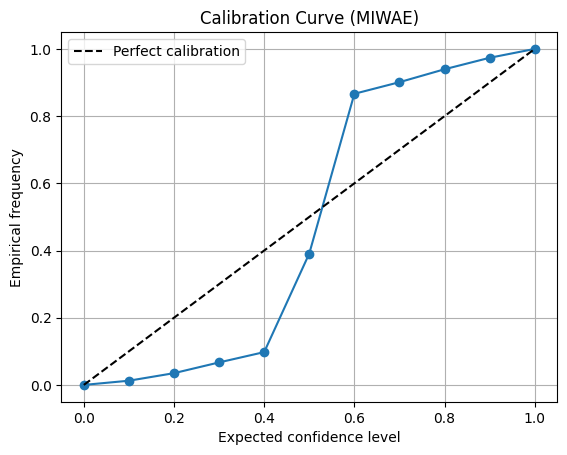

Expected Calibration Error (ECE): 0.1434


In [38]:
from scipy.stats import norm
cdf_vals = norm.cdf(GroundTruth, loc=mean_impute_bnn.detach().numpy(), scale=std_impute_bnn.detach().numpy() + 1e-6)

# Calibration curve (should be close to uniform)
quantiles = np.linspace(0, 1, 11)
proportions = [(cdf_vals < q).mean() for q in quantiles]

plt.plot(quantiles, proportions, marker='o')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Expected confidence level')
plt.ylabel('Empirical frequency')
plt.title('Calibration Curve (MIWAE)')
plt.legend()
plt.grid(True)
plt.show()

# Compute Expected Calibration Error (ECE)
ece = np.abs(np.array(proportions) - quantiles).mean()
print(f"Expected Calibration Error (ECE): {ece:.4f}")

### Comparision Bayesian, MLP and Linear Regression

### MCAR

In [ ]:

results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
numOfRuns = 3    
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 4 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=False) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor_bnn += variance_bnn  # sum across runs

variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn
)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

    #MLP Model
print("MLP........")
imputed_values_mlp = []
variance_tensor_mlp = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_mlp = {}
    for i in range(d):
        models_mlp[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_mlp = RRimputer(models_mlp,sample=False) #passing the mlp models
    imputed_mlp, maes_mlp, rmse_mlp, variance_mlp, uncertaity_log_mlp = rr_imputer_mlp.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_mlp.append(imputed_mlp.unsqueeze(0))
    variance_tensor_mlp += variance_mlp  # sum across runs

variance_tensor_mlp /= n_runs  # average aleatoric uncertainty
imputed_tensor_mlp = torch.cat(imputed_values_mlp, dim=0)  # [n_runs, n, d]
mean_impute_mlp = imputed_tensor_mlp.mean(dim=0)
std_impute_mlp = imputed_tensor_mlp.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_mlp = variance_tensor_mlp[mask]  # [0.01, 0.04]
epistemic_uncertainty_mlp = std_impute_mlp[mask]
epistemic_uncertainty_mlp_variance = epistemic_uncertainty_mlp** 2

        # combine uncertainties
total_uncertainty_mlp = (aleatoric_uncertainty_mlp + epistemic_uncertainty_mlp** 2)       
total_uncertainty_mlp_std = torch.sqrt(total_uncertainty_mlp)
mae_mlp = torch.abs(mean_impute_mlp[mask] - GroundTruth_tensor[mask]).mean().item()

total_calib_uncert_mlp, total_calib_error_mlp, total_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_mlp
)

aleatoric_calib_uncert_mlp, aleatoric_calib_error_mlp, aleatoric_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_mlp
)

epistemic_calib_uncert_mlp, epistemic_calib_error_mlp, epistemic_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_mlp_variance
)

calib_results_mcar.append({
    "method":"MLP",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_mlp,
    "total_calib_error": total_calib_error_mlp,
    "total_calib_ece": total_calib_ece_mlp,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_mlp,
    "aleatoric_calib_error": aleatoric_calib_error_mlp,
    "aleatoric_calib_ece": aleatoric_calib_ece_mlp,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_mlp,
    "epistemic_calib_error": epistemic_calib_error_mlp,
    "epistemic_calib_ece": epistemic_calib_ece_mlp
})


results_mcar.append({
           
            "method":"MLP",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_mlp.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_mlp.mean().item(),
            "total_uncertainty": total_uncertainty_mlp_std.mean().item(),
            "mae": mae_mlp,
            "maes":maes_mlp,
            "uncertaity_log":uncertaity_log_mlp
        })

    #Linear Regression
print("Linear Regression ........")
imputed_values_lr = []
variance_tensor_lr = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_lr = {}
    for i in range(d):
            models_lr[i] = LinearRR(input_dim=d_, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_lr = RRimputer(models_lr,sample=False) #passing the lr models
    imputed_lr, maes_lr, rmse_lr, variance_lr, uncertaity_log_lr = rr_imputer_lr.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_lr.append(imputed_lr.unsqueeze(0))
    variance_tensor_lr += variance_lr  # sum across runs

variance_tensor_lr /= n_runs  # average aleatoric uncertainty
imputed_tensor_lr = torch.cat(imputed_values_lr, dim=0)  # [n_runs, n, d]
mean_impute_lr = imputed_tensor_lr.mean(dim=0)
std_impute_lr = imputed_tensor_lr.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_lr = variance_tensor_lr[mask]  # [0.01, 0.04]
epistemic_uncertainty_lr = std_impute_lr[mask]
epistemic_uncertainty_lr_variance = epistemic_uncertainty_lr** 2

        # combine uncertainties
total_uncertainty_lr = (aleatoric_uncertainty_lr + epistemic_uncertainty_lr** 2)       
total_uncertainty_lr_std = torch.sqrt(total_uncertainty_lr)
mae_lr = torch.abs(mean_impute_lr[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_lr, total_calib_error_lr, total_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_lr
)

aleatoric_calib_uncert_lr, aleatoric_calib_error_lr, aleatoric_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_lr
)

epistemic_calib_uncert_lr, epistemic_calib_error_lr, epistemic_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_lr_variance
)


calib_results_mcar.append({
    "method":"Linear Regression",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_lr,
    "total_calib_error": total_calib_error_lr,
    "total_calib_ece": total_calib_ece_lr,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_lr,
    "aleatoric_calib_error": aleatoric_calib_error_lr,
    "aleatoric_calib_ece": aleatoric_calib_ece_lr,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_lr,
    "epistemic_calib_error": epistemic_calib_error_lr,
    "epistemic_calib_ece": epistemic_calib_ece_lr
})


results_mcar.append({
            "method":"Linear Regression",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_lr.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_lr.mean().item(),
            "total_uncertainty": total_uncertainty_lr_std.mean().item(),
            "mae": mae_lr,
            "maes":maes_lr,
            "uncertaity_log":uncertaity_log_lr
            
        })




df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_results30.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30.csv", index=False)


Bayesian Model........


C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\imputers.py:240: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print("log_var",log_var.grad)
C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\imputers.py:241: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad(

log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var Non

MCAR with sampling

In [ ]:

    
results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
numOfRuns = 3    
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 4 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=True) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor_bnn += variance_bnn  # sum across runs

variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn
)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

    #MLP Model
print("MLP........")
imputed_values_mlp = []
variance_tensor_mlp = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_mlp = {}
    for i in range(d):
        models_mlp[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_mlp = RRimputer(models_mlp,sample=True) #passing the mlp models
    imputed_mlp, maes_mlp, rmse_mlp, variance_mlp, uncertaity_log_mlp = rr_imputer_mlp.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_mlp.append(imputed_mlp.unsqueeze(0))
    variance_tensor_mlp += variance_mlp  # sum across runs

variance_tensor_mlp /= n_runs  # average aleatoric uncertainty
imputed_tensor_mlp = torch.cat(imputed_values_mlp, dim=0)  # [n_runs, n, d]
mean_impute_mlp = imputed_tensor_mlp.mean(dim=0)
std_impute_mlp = imputed_tensor_mlp.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_mlp = variance_tensor_mlp[mask]  # [0.01, 0.04]
epistemic_uncertainty_mlp = std_impute_mlp[mask]
epistemic_uncertainty_mlp_variance = epistemic_uncertainty_mlp** 2

        # combine uncertainties
total_uncertainty_mlp = (aleatoric_uncertainty_mlp + epistemic_uncertainty_mlp** 2)       
total_uncertainty_mlp_std = torch.sqrt(total_uncertainty_mlp)
mae_mlp = torch.abs(mean_impute_mlp[mask] - GroundTruth_tensor[mask]).mean().item()

total_calib_uncert_mlp, total_calib_error_mlp, total_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_mlp
)

aleatoric_calib_uncert_mlp, aleatoric_calib_error_mlp, aleatoric_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_mlp
)

epistemic_calib_uncert_mlp, epistemic_calib_error_mlp, epistemic_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_mlp_variance
)

calib_results_mcar.append({
    "method":"MLP",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_mlp,
    "total_calib_error": total_calib_error_mlp,
    "total_calib_ece": total_calib_ece_mlp,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_mlp,
    "aleatoric_calib_error": aleatoric_calib_error_mlp,
    "aleatoric_calib_ece": aleatoric_calib_ece_mlp,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_mlp,
    "epistemic_calib_error": epistemic_calib_error_mlp,
    "epistemic_calib_ece": epistemic_calib_ece_mlp
})


results_mcar.append({
           
            "method":"MLP",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_mlp.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_mlp.mean().item(),
            "total_uncertainty": total_uncertainty_mlp_std.mean().item(),
            "mae": mae_mlp,
            "maes":maes_mlp,
            "uncertaity_log":uncertaity_log_mlp
        })

    #Linear Regression
print("Linear Regression ........")
imputed_values_lr = []
variance_tensor_lr = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_lr = {}
    for i in range(d):
            models_lr[i] = LinearRR(input_dim=d_, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_lr = RRimputer(models_lr,sample=True) #passing the lr models
    imputed_lr, maes_lr, rmse_lr, variance_lr, uncertaity_log_lr = rr_imputer_lr.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_lr.append(imputed_lr.unsqueeze(0))
    variance_tensor_lr += variance_lr  # sum across runs

variance_tensor_lr /= n_runs  # average aleatoric uncertainty
imputed_tensor_lr = torch.cat(imputed_values_lr, dim=0)  # [n_runs, n, d]
mean_impute_lr = imputed_tensor_lr.mean(dim=0)
std_impute_lr = imputed_tensor_lr.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_lr = variance_tensor_lr[mask]  # [0.01, 0.04]
epistemic_uncertainty_lr = std_impute_lr[mask]
epistemic_uncertainty_lr_variance = epistemic_uncertainty_lr** 2

        # combine uncertainties
total_uncertainty_lr = (aleatoric_uncertainty_lr + epistemic_uncertainty_lr** 2)       
total_uncertainty_lr_std = torch.sqrt(total_uncertainty_lr)
mae_lr = torch.abs(mean_impute_lr[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_lr, total_calib_error_lr, total_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_lr
)

aleatoric_calib_uncert_lr, aleatoric_calib_error_lr, aleatoric_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_lr
)

epistemic_calib_uncert_lr, epistemic_calib_error_lr, epistemic_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_lr_variance
)


calib_results_mcar.append({
    "method":"Linear Regression",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_lr,
    "total_calib_error": total_calib_error_lr,
    "total_calib_ece": total_calib_ece_lr,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_lr,
    "aleatoric_calib_error": aleatoric_calib_error_lr,
    "aleatoric_calib_ece": aleatoric_calib_ece_lr,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_lr,
    "epistemic_calib_error": epistemic_calib_error_lr,
    "epistemic_calib_ece": epistemic_calib_ece_lr
})


results_mcar.append({
            "method":"Linear Regression",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_lr.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_lr.mean().item(),
            "total_uncertainty": total_uncertainty_lr_std.mean().item(),
            "mae": mae_lr,
            "maes":maes_lr,
            "uncertaity_log":uncertaity_log_lr
            
        })





df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_sampled_results30.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_sampled_results30.csv", index=False)


Bayesian Model........


C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\imputers.py:240: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print("log_var",log_var.grad)
C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\imputers.py:241: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad(

log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean No

In [ ]:

results_mcar = []
calib_results_mcar = []
missing_rate = 10

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
numOfRuns = 3    
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 4 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=False) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor_bnn += variance_bnn  # sum across runs

variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn
)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

    #MLP Model
print("MLP........")
imputed_values_mlp = []
variance_tensor_mlp = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_mlp = {}
    for i in range(d):
        models_mlp[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_mlp = RRimputer(models_mlp,sample=False) #passing the mlp models
    imputed_mlp, maes_mlp, rmse_mlp, variance_mlp, uncertaity_log_mlp = rr_imputer_mlp.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_mlp.append(imputed_mlp.unsqueeze(0))
    variance_tensor_mlp += variance_mlp  # sum across runs

variance_tensor_mlp /= n_runs  # average aleatoric uncertainty
imputed_tensor_mlp = torch.cat(imputed_values_mlp, dim=0)  # [n_runs, n, d]
mean_impute_mlp = imputed_tensor_mlp.mean(dim=0)
std_impute_mlp = imputed_tensor_mlp.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_mlp = variance_tensor_mlp[mask]  # [0.01, 0.04]
epistemic_uncertainty_mlp = std_impute_mlp[mask]
epistemic_uncertainty_mlp_variance = epistemic_uncertainty_mlp** 2

        # combine uncertainties
total_uncertainty_mlp = (aleatoric_uncertainty_mlp + epistemic_uncertainty_mlp** 2)       
total_uncertainty_mlp_std = torch.sqrt(total_uncertainty_mlp)
mae_mlp = torch.abs(mean_impute_mlp[mask] - GroundTruth_tensor[mask]).mean().item()

total_calib_uncert_mlp, total_calib_error_mlp, total_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_mlp
)

aleatoric_calib_uncert_mlp, aleatoric_calib_error_mlp, aleatoric_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_mlp
)

epistemic_calib_uncert_mlp, epistemic_calib_error_mlp, epistemic_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_mlp_variance
)

calib_results_mcar.append({
    "method":"MLP",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_mlp,
    "total_calib_error": total_calib_error_mlp,
    "total_calib_ece": total_calib_ece_mlp,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_mlp,
    "aleatoric_calib_error": aleatoric_calib_error_mlp,
    "aleatoric_calib_ece": aleatoric_calib_ece_mlp,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_mlp,
    "epistemic_calib_error": epistemic_calib_error_mlp,
    "epistemic_calib_ece": epistemic_calib_ece_mlp
})


results_mcar.append({
           
            "method":"MLP",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_mlp.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_mlp.mean().item(),
            "total_uncertainty": total_uncertainty_mlp_std.mean().item(),
            "mae": mae_mlp,
            "maes":maes_mlp,
            "uncertaity_log":uncertaity_log_mlp
        })

    #Linear Regression
print("Linear Regression ........")
imputed_values_lr = []
variance_tensor_lr = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_lr = {}
    for i in range(d):
            models_lr[i] = LinearRR(input_dim=d_, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_lr = RRimputer(models_lr,sample=False) #passing the lr models
    imputed_lr, maes_lr, rmse_lr, variance_lr, uncertaity_log_lr = rr_imputer_lr.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_lr.append(imputed_lr.unsqueeze(0))
    variance_tensor_lr += variance_lr  # sum across runs

variance_tensor_lr /= n_runs  # average aleatoric uncertainty
imputed_tensor_lr = torch.cat(imputed_values_lr, dim=0)  # [n_runs, n, d]
mean_impute_lr = imputed_tensor_lr.mean(dim=0)
std_impute_lr = imputed_tensor_lr.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_lr = variance_tensor_lr[mask]  # [0.01, 0.04]
epistemic_uncertainty_lr = std_impute_lr[mask]
epistemic_uncertainty_lr_variance = epistemic_uncertainty_lr** 2

        # combine uncertainties
total_uncertainty_lr = (aleatoric_uncertainty_lr + epistemic_uncertainty_lr** 2)       
total_uncertainty_lr_std = torch.sqrt(total_uncertainty_lr)
mae_lr = torch.abs(mean_impute_lr[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_lr, total_calib_error_lr, total_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_lr
)

aleatoric_calib_uncert_lr, aleatoric_calib_error_lr, aleatoric_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_lr
)

epistemic_calib_uncert_lr, epistemic_calib_error_lr, epistemic_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_lr_variance
)


calib_results_mcar.append({
    "method":"Linear Regression",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_lr,
    "total_calib_error": total_calib_error_lr,
    "total_calib_ece": total_calib_ece_lr,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_lr,
    "aleatoric_calib_error": aleatoric_calib_error_lr,
    "aleatoric_calib_ece": aleatoric_calib_ece_lr,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_lr,
    "epistemic_calib_error": epistemic_calib_error_lr,
    "epistemic_calib_ece": epistemic_calib_ece_lr
})


results_mcar.append({
            "method":"Linear Regression",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_lr.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_lr.mean().item(),
            "total_uncertainty": total_uncertainty_lr_std.mean().item(),
            "mae": mae_lr,
            "maes":maes_lr,
            "uncertaity_log":uncertaity_log_lr
            
        })




df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_results10.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results10.csv", index=False)


Bayesian Model........
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var None
mean None
log_var Non

MCAR with sampling

In [ ]:

    
results_mcar = []
calib_results_mcar = []
missing_rate = 10

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
numOfRuns = 3    
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 4 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=True) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor_bnn += variance_bnn  # sum across runs

variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn
)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

    #MLP Model
print("MLP........")
imputed_values_mlp = []
variance_tensor_mlp = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_mlp = {}
    for i in range(d):
        models_mlp[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_mlp = RRimputer(models_mlp,sample=True) #passing the mlp models
    imputed_mlp, maes_mlp, rmse_mlp, variance_mlp, uncertaity_log_mlp = rr_imputer_mlp.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_mlp.append(imputed_mlp.unsqueeze(0))
    variance_tensor_mlp += variance_mlp  # sum across runs

variance_tensor_mlp /= n_runs  # average aleatoric uncertainty
imputed_tensor_mlp = torch.cat(imputed_values_mlp, dim=0)  # [n_runs, n, d]
mean_impute_mlp = imputed_tensor_mlp.mean(dim=0)
std_impute_mlp = imputed_tensor_mlp.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_mlp = variance_tensor_mlp[mask]  # [0.01, 0.04]
epistemic_uncertainty_mlp = std_impute_mlp[mask]
epistemic_uncertainty_mlp_variance = epistemic_uncertainty_mlp** 2

        # combine uncertainties
total_uncertainty_mlp = (aleatoric_uncertainty_mlp + epistemic_uncertainty_mlp** 2)       
total_uncertainty_mlp_std = torch.sqrt(total_uncertainty_mlp)
mae_mlp = torch.abs(mean_impute_mlp[mask] - GroundTruth_tensor[mask]).mean().item()

total_calib_uncert_mlp, total_calib_error_mlp, total_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_mlp
)

aleatoric_calib_uncert_mlp, aleatoric_calib_error_mlp, aleatoric_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_mlp
)

epistemic_calib_uncert_mlp, epistemic_calib_error_mlp, epistemic_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_mlp_variance
)

calib_results_mcar.append({
    "method":"MLP",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_mlp,
    "total_calib_error": total_calib_error_mlp,
    "total_calib_ece": total_calib_ece_mlp,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_mlp,
    "aleatoric_calib_error": aleatoric_calib_error_mlp,
    "aleatoric_calib_ece": aleatoric_calib_ece_mlp,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_mlp,
    "epistemic_calib_error": epistemic_calib_error_mlp,
    "epistemic_calib_ece": epistemic_calib_ece_mlp
})


results_mcar.append({
           
            "method":"MLP",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_mlp.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_mlp.mean().item(),
            "total_uncertainty": total_uncertainty_mlp_std.mean().item(),
            "mae": mae_mlp,
            "maes":maes_mlp,
            "uncertaity_log":uncertaity_log_mlp
        })

    #Linear Regression
print("Linear Regression ........")
imputed_values_lr = []
variance_tensor_lr = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_lr = {}
    for i in range(d):
            models_lr[i] = LinearRR(input_dim=d_, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_lr = RRimputer(models_lr,sample=True) #passing the lr models
    imputed_lr, maes_lr, rmse_lr, variance_lr, uncertaity_log_lr = rr_imputer_lr.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_lr.append(imputed_lr.unsqueeze(0))
    variance_tensor_lr += variance_lr  # sum across runs

variance_tensor_lr /= n_runs  # average aleatoric uncertainty
imputed_tensor_lr = torch.cat(imputed_values_lr, dim=0)  # [n_runs, n, d]
mean_impute_lr = imputed_tensor_lr.mean(dim=0)
std_impute_lr = imputed_tensor_lr.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_lr = variance_tensor_lr[mask]  # [0.01, 0.04]
epistemic_uncertainty_lr = std_impute_lr[mask]
epistemic_uncertainty_lr_variance = epistemic_uncertainty_lr** 2

        # combine uncertainties
total_uncertainty_lr = (aleatoric_uncertainty_lr + epistemic_uncertainty_lr** 2)       
total_uncertainty_lr_std = torch.sqrt(total_uncertainty_lr)
mae_lr = torch.abs(mean_impute_lr[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_lr, total_calib_error_lr, total_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_lr
)

aleatoric_calib_uncert_lr, aleatoric_calib_error_lr, aleatoric_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_lr
)

epistemic_calib_uncert_lr, epistemic_calib_error_lr, epistemic_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_lr_variance
)


calib_results_mcar.append({
    "method":"Linear Regression",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_lr,
    "total_calib_error": total_calib_error_lr,
    "total_calib_ece": total_calib_ece_lr,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_lr,
    "aleatoric_calib_error": aleatoric_calib_error_lr,
    "aleatoric_calib_ece": aleatoric_calib_ece_lr,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_lr,
    "epistemic_calib_error": epistemic_calib_error_lr,
    "epistemic_calib_ece": epistemic_calib_ece_lr
})


results_mcar.append({
            "method":"Linear Regression",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_lr.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_lr.mean().item(),
            "total_uncertainty": total_uncertainty_lr_std.mean().item(),
            "mae": mae_lr,
            "maes":maes_lr,
            "uncertaity_log":uncertaity_log_lr
            
        })





df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_sampled_results10.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_sampled_results10.csv", index=False)


Bayesian Model........
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample None
log_var None
mean None
sample No

## Updated RR

In [ ]:

results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
numOfRuns = 3    
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 4 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer_nll(models_bnn,sample=False) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor_bnn += variance_bnn  # sum across runs

variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn
)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

    #MLP Model
print("MLP........")
imputed_values_mlp = []
variance_tensor_mlp = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_mlp = {}
    for i in range(d):
        models_mlp[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_mlp = RRimputer_nll(models_mlp,sample=False) #passing the mlp models
    imputed_mlp, maes_mlp, rmse_mlp, variance_mlp, uncertaity_log_mlp = rr_imputer_mlp.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_mlp.append(imputed_mlp.unsqueeze(0))
    variance_tensor_mlp += variance_mlp  # sum across runs

variance_tensor_mlp /= n_runs  # average aleatoric uncertainty
imputed_tensor_mlp = torch.cat(imputed_values_mlp, dim=0)  # [n_runs, n, d]
mean_impute_mlp = imputed_tensor_mlp.mean(dim=0)
std_impute_mlp = imputed_tensor_mlp.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_mlp = variance_tensor_mlp[mask]  # [0.01, 0.04]
epistemic_uncertainty_mlp = std_impute_mlp[mask]
epistemic_uncertainty_mlp_variance = epistemic_uncertainty_mlp** 2

        # combine uncertainties
total_uncertainty_mlp = (aleatoric_uncertainty_mlp + epistemic_uncertainty_mlp** 2)       
total_uncertainty_mlp_std = torch.sqrt(total_uncertainty_mlp)
mae_mlp = torch.abs(mean_impute_mlp[mask] - GroundTruth_tensor[mask]).mean().item()

total_calib_uncert_mlp, total_calib_error_mlp, total_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_mlp
)

aleatoric_calib_uncert_mlp, aleatoric_calib_error_mlp, aleatoric_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_mlp
)

epistemic_calib_uncert_mlp, epistemic_calib_error_mlp, epistemic_calib_ece_mlp = calibration_curve(
    pred=mean_impute_mlp[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_mlp_variance
)

calib_results_mcar.append({
    "method":"MLP",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_mlp,
    "total_calib_error": total_calib_error_mlp,
    "total_calib_ece": total_calib_ece_mlp,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_mlp,
    "aleatoric_calib_error": aleatoric_calib_error_mlp,
    "aleatoric_calib_ece": aleatoric_calib_ece_mlp,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_mlp,
    "epistemic_calib_error": epistemic_calib_error_mlp,
    "epistemic_calib_ece": epistemic_calib_ece_mlp
})


results_mcar.append({
           
            "method":"MLP",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_mlp.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_mlp.mean().item(),
            "total_uncertainty": total_uncertainty_mlp_std.mean().item(),
            "mae": mae_mlp,
            "maes":maes_mlp,
            "uncertaity_log":uncertaity_log_mlp
        })

    #Linear Regression
print("Linear Regression ........")
imputed_values_lr = []
variance_tensor_lr = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_lr = {}
    for i in range(d):
            models_lr[i] = LinearRR(input_dim=d_, output_dim=1).double()
        
        #Create the imputer
    rr_imputer_lr = RRimputer_nll(models_lr,sample=False) #passing the lr models
    imputed_lr, maes_lr, rmse_lr, variance_lr, uncertaity_log_lr = rr_imputer_lr.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_lr.append(imputed_lr.unsqueeze(0))
    variance_tensor_lr += variance_lr  # sum across runs

variance_tensor_lr /= n_runs  # average aleatoric uncertainty
imputed_tensor_lr = torch.cat(imputed_values_lr, dim=0)  # [n_runs, n, d]
mean_impute_lr = imputed_tensor_lr.mean(dim=0)
std_impute_lr = imputed_tensor_lr.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
aleatoric_uncertainty_lr = variance_tensor_lr[mask]  # [0.01, 0.04]
epistemic_uncertainty_lr = std_impute_lr[mask]
epistemic_uncertainty_lr_variance = epistemic_uncertainty_lr** 2

        # combine uncertainties
total_uncertainty_lr = (aleatoric_uncertainty_lr + epistemic_uncertainty_lr** 2)       
total_uncertainty_lr_std = torch.sqrt(total_uncertainty_lr)
mae_lr = torch.abs(mean_impute_lr[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_lr, total_calib_error_lr, total_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_lr
)

aleatoric_calib_uncert_lr, aleatoric_calib_error_lr, aleatoric_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_lr
)

epistemic_calib_uncert_lr, epistemic_calib_error_lr, epistemic_calib_ece_lr = calibration_curve(
    pred=mean_impute_lr[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_lr_variance
)


calib_results_mcar.append({
    "method":"Linear Regression",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_lr,
    "total_calib_error": total_calib_error_lr,
    "total_calib_ece": total_calib_ece_lr,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_lr,
    "aleatoric_calib_error": aleatoric_calib_error_lr,
    "aleatoric_calib_ece": aleatoric_calib_ece_lr,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_lr,
    "epistemic_calib_error": epistemic_calib_error_lr,
    "epistemic_calib_ece": epistemic_calib_ece_lr
})


results_mcar.append({
            "method":"Linear Regression",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_lr.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_lr.mean().item(),
            "total_uncertainty": total_uncertainty_lr_std.mean().item(),
            "mae": mae_lr,
            "maes":maes_lr,
            "uncertaity_log":uncertaity_log_lr
            
        })




df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_comparision_updated_results30.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_updated_results30.csv", index=False)


Bayesian Model........
MLP........
Linear Regression ........


### Visualization

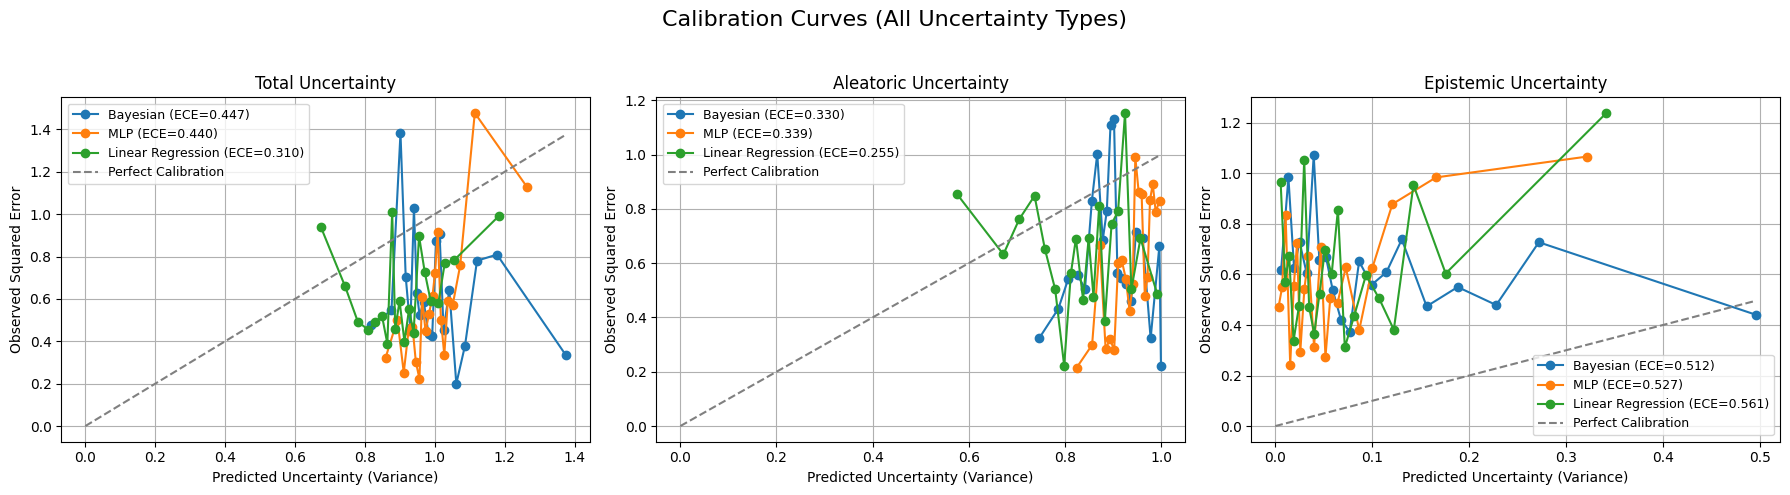

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


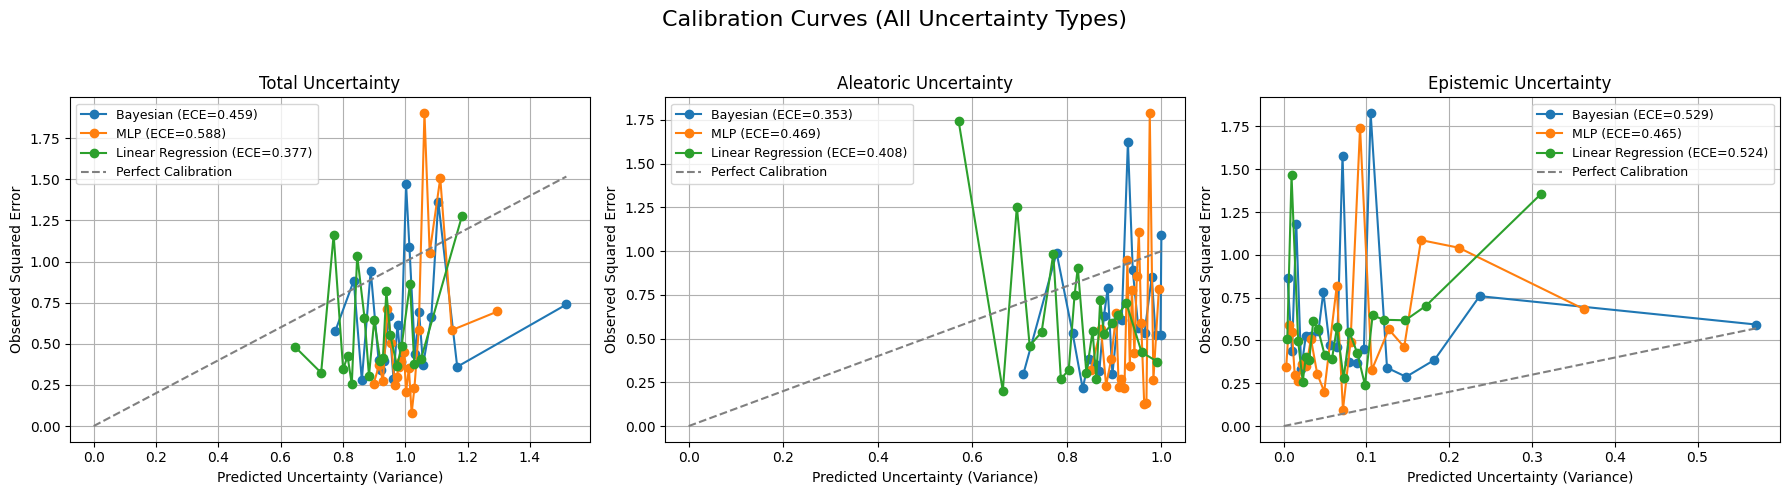

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results10.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


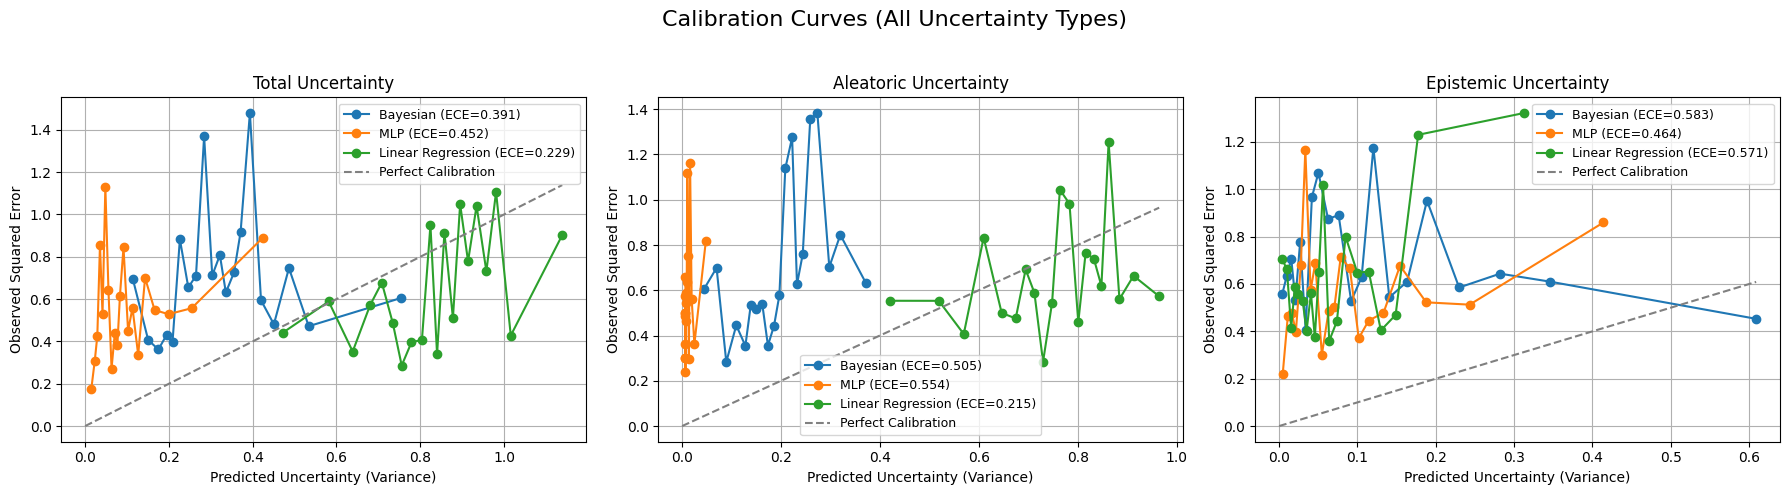

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_sampled_results30.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


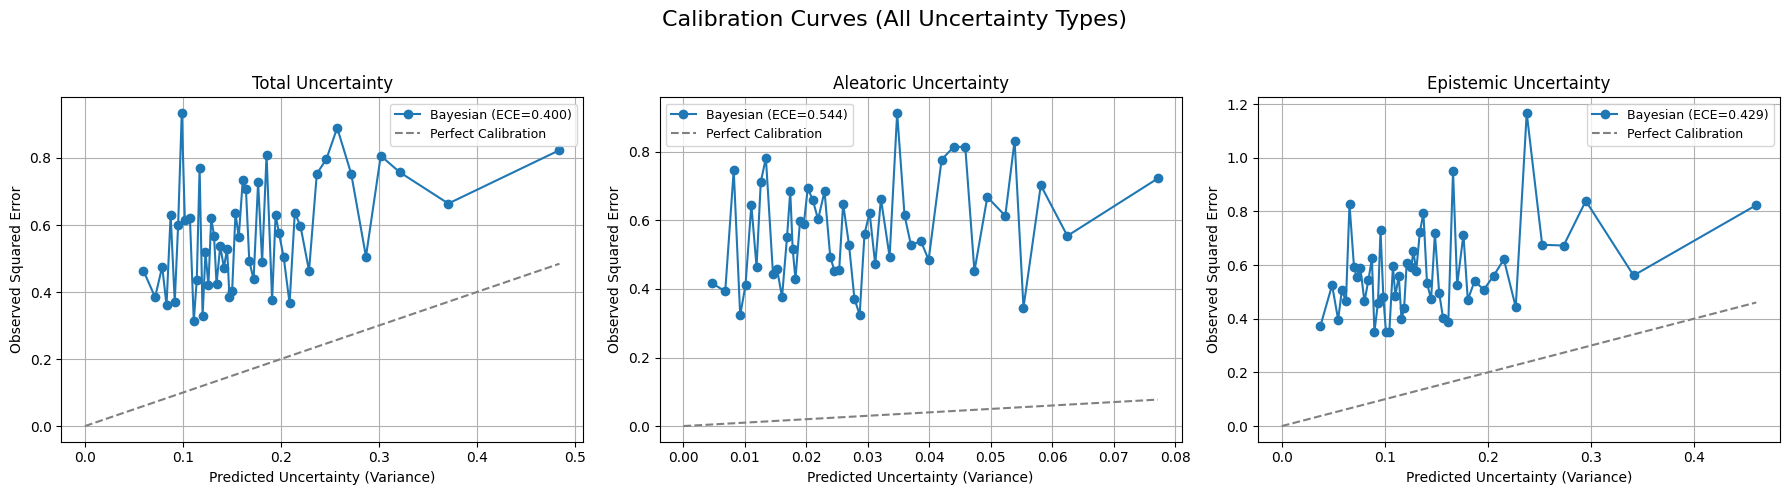

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


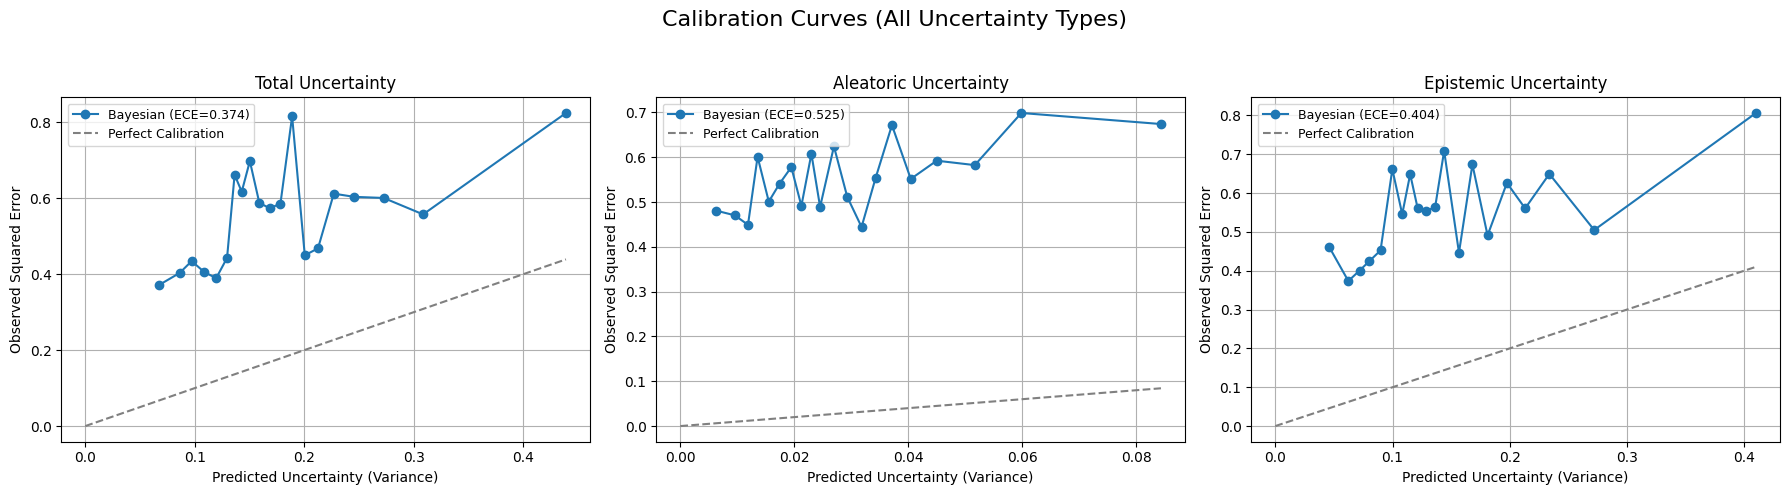

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


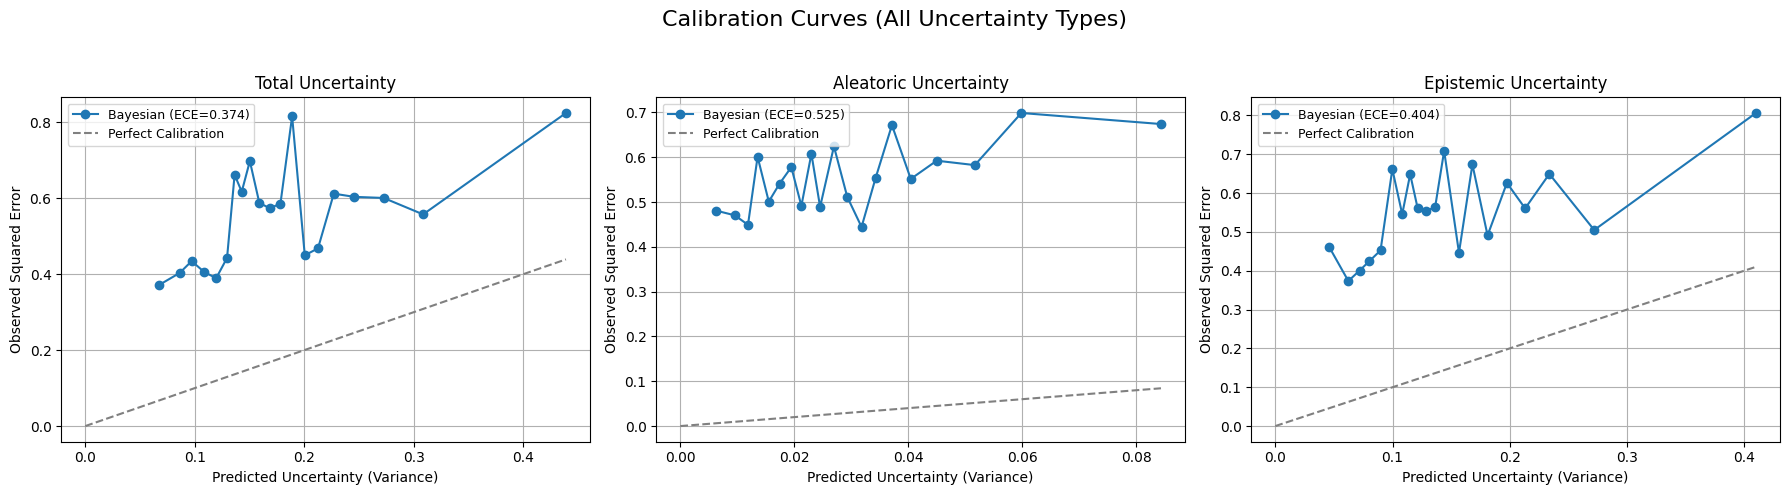

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()


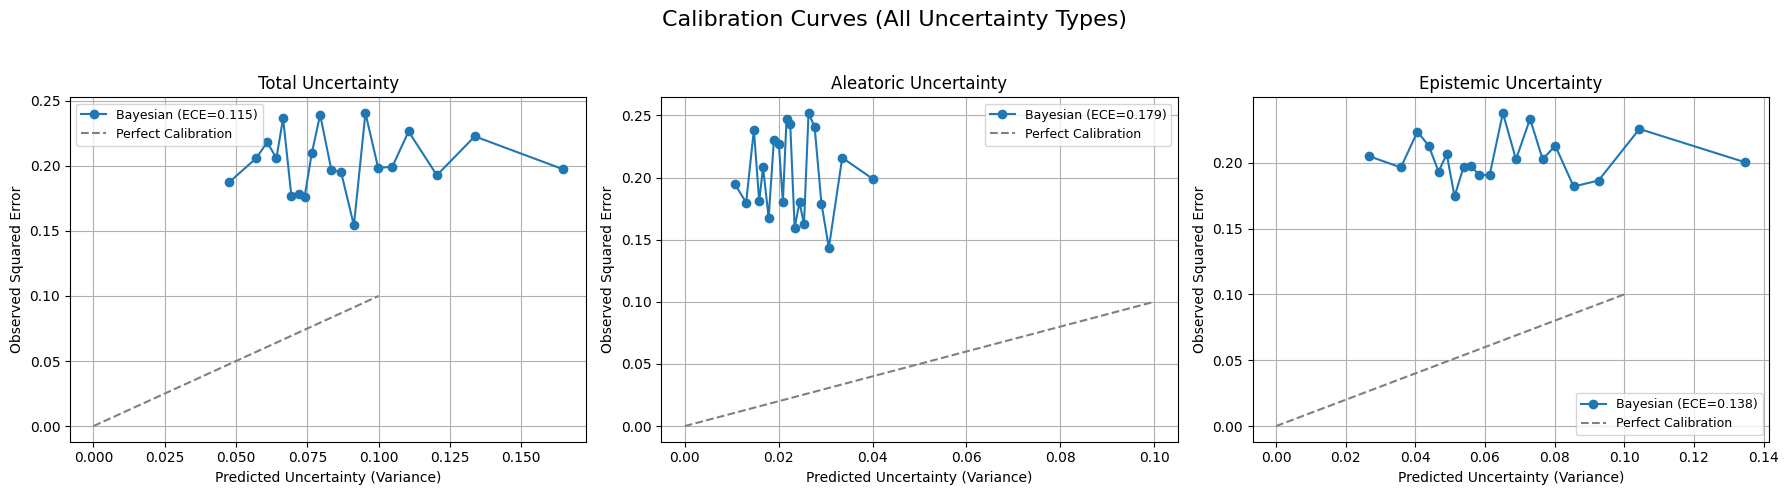

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_calib_results30_quantile_rmse.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, 0.100], [0, 0.100], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig("calibration_curves_all_types.png", dpi=300)
plt.show()
